  IRIS DATASET — EXPLORATION REPORT

📐 Shape: (150, 5)

📋 Columns: ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']

🔍 First 5 Rows:
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa

📊 Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   sepal_length  150 non-null    float64 
 1   sepal_width   150 non-null    float64 
 2   petal_length  150 non-null    float64 
 3   petal_width   150 non-null    float64 
 4   species       150 non-null    category
dtypes: category(1), float64(

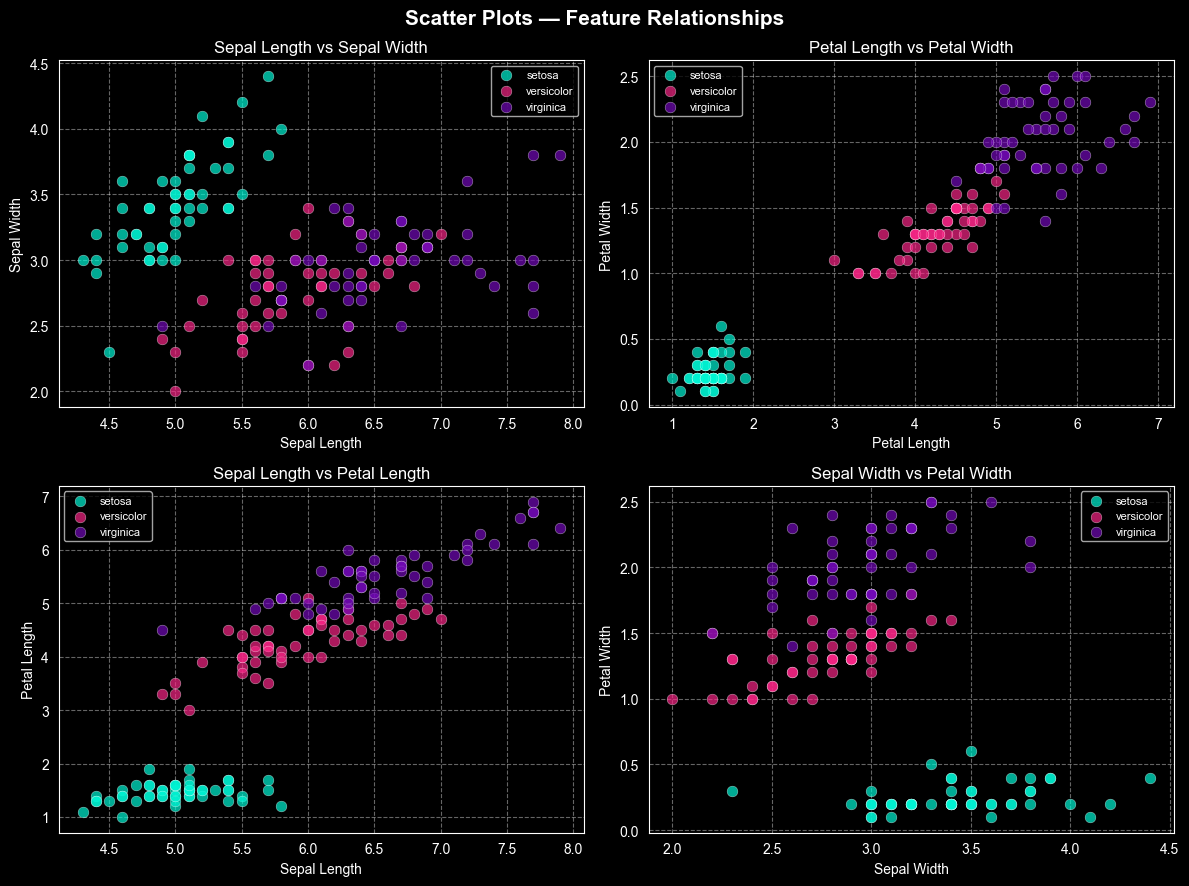

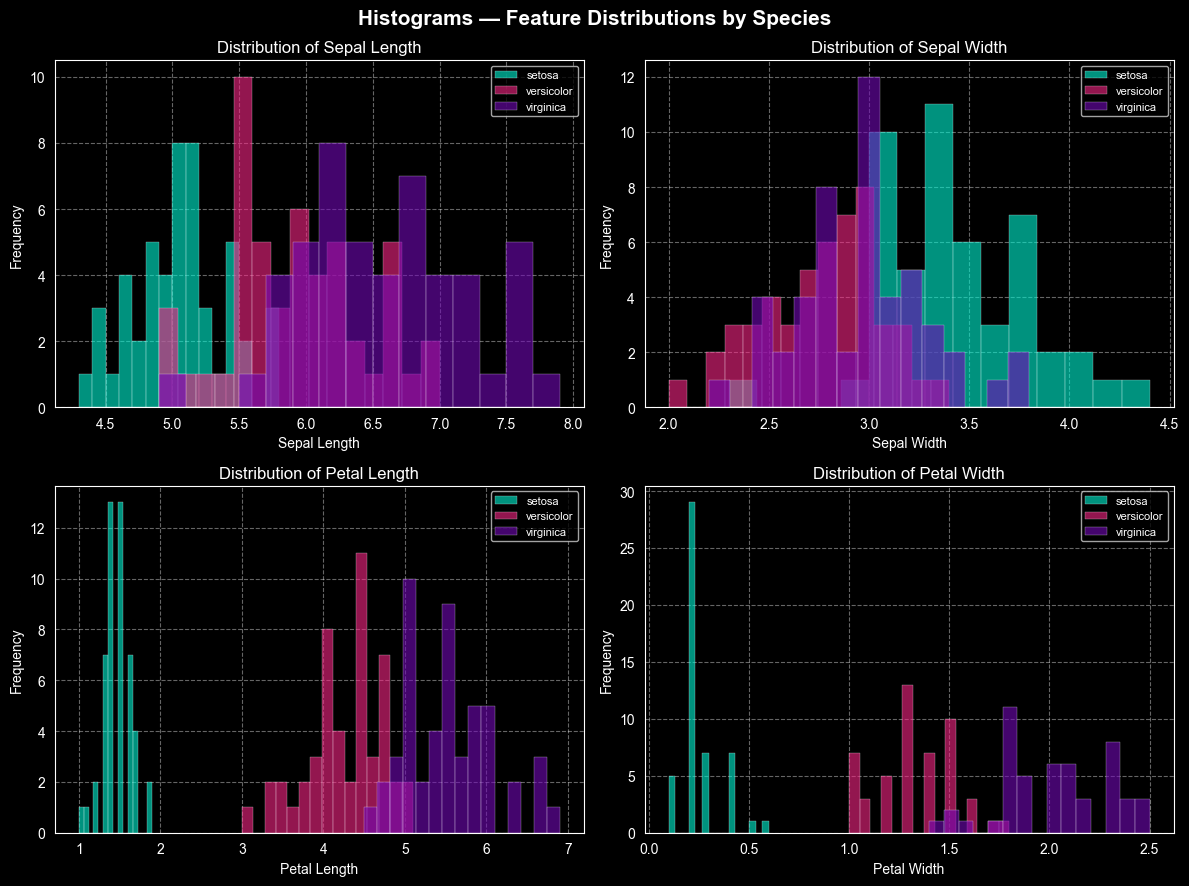

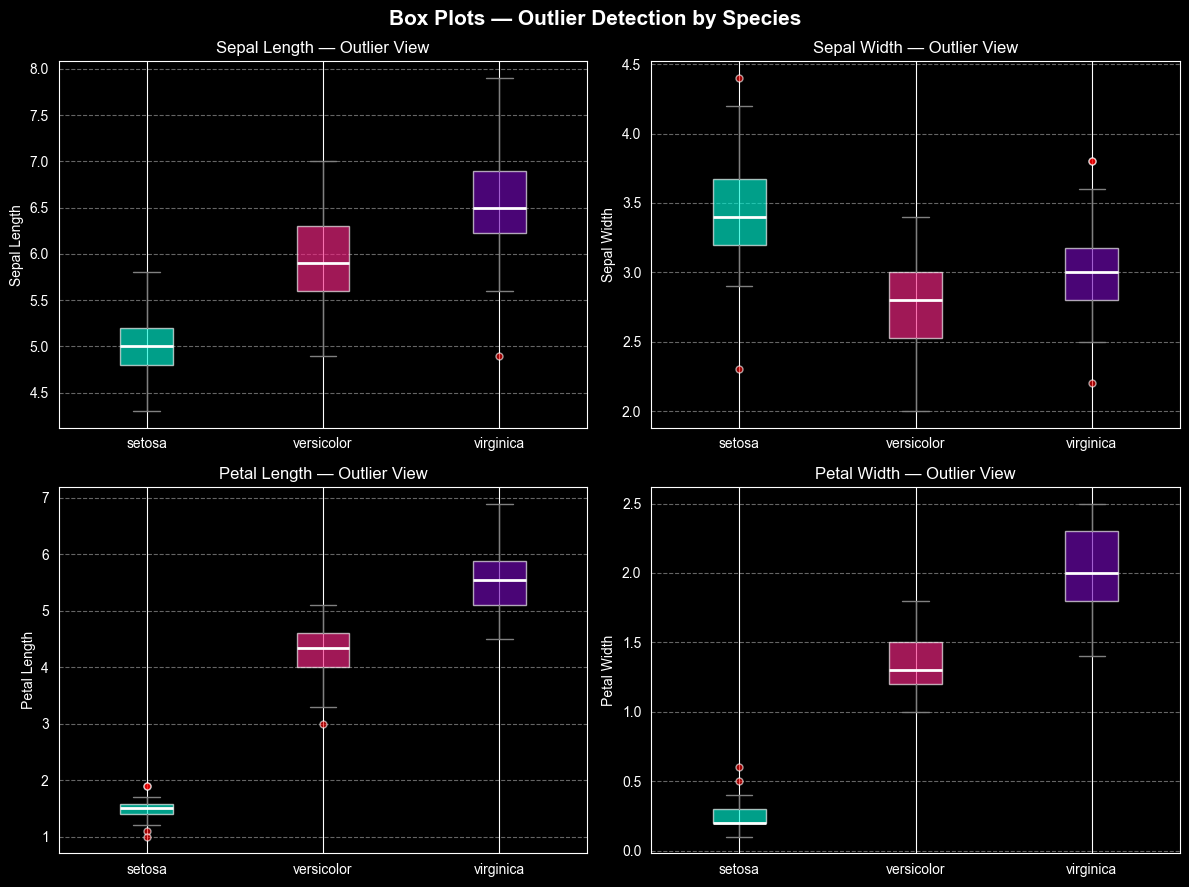

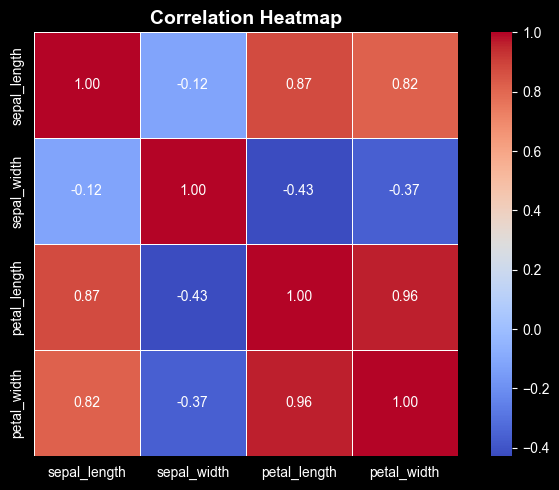


 All 4 plots saved successfully!


In [1]:
# ============================================================
#   TASK 1: Exploring and Visualizing the Iris Dataset
#   Tools: pandas, matplotlib, seaborn
# ============================================================

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris   # local source, no internet needed

# ─────────────────────────────────────────
# STEP 1: LOAD THE DATASET
# ─────────────────────────────────────────

# Load Iris dataset and build a DataFrame
iris_raw = load_iris()
df = pd.DataFrame(iris_raw.data, columns=iris_raw.feature_names)
df['species'] = pd.Categorical.from_codes(iris_raw.target, iris_raw.target_names)

# Rename columns to shorter names for easier use
df.columns = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']

# ─────────────────────────────────────────
# STEP 2: BASIC INSPECTION
# ─────────────────────────────────────────

print("=" * 50)
print("  IRIS DATASET — EXPLORATION REPORT")
print("=" * 50)

# Shape: rows x columns
print("\n📐 Shape:", df.shape)

# Column names
print("\n📋 Columns:", df.columns.tolist())

# First 5 rows
print("\n🔍 First 5 Rows:")
print(df.head())

# ─────────────────────────────────────────
# STEP 3: INFO & DESCRIBE
# ─────────────────────────────────────────

# Data types, non-null counts, memory usage
print("\n📊 Dataset Info:")
df.info()

# Summary statistics (count, mean, std, min, quartiles, max)
print("\n📈 Descriptive Statistics:")
print(df.describe())

# Class distribution
print("\n🌸 Species Count:")
print(df['species'].value_counts())

# ─────────────────────────────────────────
# STEP 4: VISUALIZATION SETUP
# ─────────────────────────────────────────

# Color palette for 3 species
palette = {
    'setosa':     '#00f5d4',
    'versicolor': '#f72585',
    'virginica':  '#7209b7'
}

# ── PLOT 1: SCATTER PLOTS ────────────────
# Shows relationships (correlation) between pairs of features

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
fig.suptitle('Scatter Plots — Feature Relationships', fontsize=15, fontweight='bold')

pairs = [
    ('sepal_length', 'sepal_width'),
    ('petal_length', 'petal_width'),
    ('sepal_length', 'petal_length'),
    ('sepal_width',  'petal_width'),
]

for ax, (x_col, y_col) in zip(axes.flat, pairs):
    for species, color in palette.items():
        subset = df[df['species'] == species]
        ax.scatter(subset[x_col], subset[y_col],
                   label=species, color=color,
                   alpha=0.7, edgecolors='white', linewidths=0.3, s=60)
    ax.set_xlabel(x_col.replace('_', ' ').title())
    ax.set_ylabel(y_col.replace('_', ' ').title())
    ax.set_title(f'{x_col.replace("_"," ").title()} vs {y_col.replace("_"," ").title()}')
    ax.legend(fontsize=8)
    ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('scatter_plots.png', dpi=150, bbox_inches='tight')
plt.show()

# ── PLOT 2: HISTOGRAMS ────────────────────
# Shows the distribution (spread) of each feature per species

features = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
fig.suptitle('Histograms — Feature Distributions by Species', fontsize=15, fontweight='bold')

for ax, feat in zip(axes.flat, features):
    for species, color in palette.items():
        data = df[df['species'] == species][feat]
        ax.hist(data, bins=15, alpha=0.6, color=color,
                label=species, edgecolor='white', linewidth=0.3)
    ax.set_xlabel(feat.replace('_', ' ').title())
    ax.set_ylabel('Frequency')
    ax.set_title(f'Distribution of {feat.replace("_"," ").title()}')
    ax.legend(fontsize=8)
    ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('histograms.png', dpi=150, bbox_inches='tight')
plt.show()

# ── PLOT 3: BOX PLOTS ─────────────────────
# Shows median, spread, and outliers per species for each feature

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
fig.suptitle('Box Plots — Outlier Detection by Species', fontsize=15, fontweight='bold')

for ax, feat in zip(axes.flat, features):
    # Group data by species for boxplot
    groups = [df[df['species'] == sp][feat].values for sp in palette.keys()]

    bp = ax.boxplot(groups,
                    patch_artist=True,                          # filled boxes
                    medianprops=dict(color='white', linewidth=2),
                    whiskerprops=dict(color='gray'),
                    capprops=dict(color='gray'),
                    flierprops=dict(marker='o', markerfacecolor='red',
                                   markersize=5, alpha=0.6))   # outliers in red

    # Apply species colors to each box
    for patch, color in zip(bp['boxes'], palette.values()):
        patch.set_facecolor(color)
        patch.set_alpha(0.65)

    ax.set_xticklabels(list(palette.keys()))
    ax.set_ylabel(feat.replace('_', ' ').title())
    ax.set_title(f'{feat.replace("_"," ").title()} — Outlier View')
    ax.grid(True, axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('box_plots.png', dpi=150, bbox_inches='tight')
plt.show()

# ── BONUS PLOT: CORRELATION HEATMAP ──────
# Shows which features are most correlated with each other

plt.figure(figsize=(7, 5))
corr = df.drop(columns='species').corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True)
plt.title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n All 4 plots saved successfully!")